# 🍷 Da Química ao Rótulo: Classificando Vinhos com Machine Learning

**POSTECH FIAP — Data Analytics | Tech Challenge Fase 2**



### 👥 Equipe

- **Maycon Nunes** — Regressão Logística
- **Carlos Freitas** — Random Forest
- **Vinicius Lopes** — XGBoost

## 📌 Introdução

A avaliação da qualidade do vinho é tradicionalmente realizada por 
especialistas humanos, um processo subjetivo, caro e demorado. 
Com o avanço do aprendizado de máquina, tornou-se possível utilizar 
características físico-químicas mensuráveis em laboratório para prever 
essa qualidade de forma objetiva e escalável.

Este trabalho utiliza o **Wine Quality Dataset**, contendo **1143 amostras 
de vinho tinto português "Vinho Verde"**, para desenvolver modelos preditivos 
capazes de classificar um vinho como:

- ✅ **Alta Qualidade** → nota ≥ 7
- ❌ **Baixa/Média Qualidade** → nota < 7

Foram treinados e comparados três modelos de classificação: a **Regressão 
Logística**, modelo linear que interpreta o peso de cada variável; o 
**Random Forest**, ensemble de árvores robusto que gera feature importance; 
e o **XGBoost**, técnica de gradient boosting considerada state-of-the-art 
em datasets tabulares.

A avaliação dos modelos considerou não apenas a acurácia geral, mas 
métricas como **F1-score** e **recall** — mais adequadas ao desbalanceamento 
natural do dataset, onde apenas **14% dos vinhos são de alta qualidade**.

## 📊 Sobre o Dataset

Este dataset contém informações sobre variantes tintas do vinho português 
**"Vinho Verde"**, descrevendo a quantidade de diversos componentes químicos 
presentes no vinho e seus efeitos na qualidade final.

> **Fonte:** [Wine Quality Dataset — Kaggle](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset)  
> **Referência acadêmica:** Cortez et al., 2009 — *Modeling wine preferences 
> by data mining from physicochemical properties*

### Variáveis de entrada (testes físico-químicos):

- **fixed acidity** — Ácidos não voláteis que adicionam frescor e harmonia ao sabor
- **volatile acidity** — Ácidos detectáveis pelo olfato — níveis altos indicam defeito no vinho
- **citric acid** — Usado para aumentar acidez e prevenir infecções fúngicas
- **residual sugar** — Açúcar da uva que não fermentou em álcool
- **chlorides** — Minerais que afetam a estrutura do vinho
- **free sulfur dioxide** — Conservante com propriedades antibacterianas e antioxidantes
- **total sulfur dioxide** — SO2 total — livre e combinado com outras substâncias
- **density** — Influenciada pelo teor alcoólico e açúcar
- **pH** — Mede a acidez — ideal entre 2.9 e 4.2 para vinhos
- **sulphates** — Subproduto da fermentação do açúcar em álcool
- **alcohol** — Influenciado pela variedade da uva, métodos de produção e ambiente
- 🎯 **quality** — **Variável alvo — nota de 0 a 10 atribuída por especialistas**

## 🔍 Análise Exploratória de Dados (EDA)

Antes de desenvolver qualquer modelo, é fundamental compreender 
a estrutura e o comportamento dos dados. Esta seção investiga:

- A distribuição das variáveis físico-químicas
- As correlações entre as variáveis e a qualidade do vinho
- O balanceamento das classes
- A presença de outliers ou valores inconsistentes

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np

In [2]:
# Carregando o dataset dos vinhos
df_vinhos = pd.read_csv('..//data/WineQT.csv')

In [3]:
# Explorando as primeiras linhas do DataFrame
df_vinhos.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
# Explorando as últimas linhas do DataFrame
df_vinhos.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


In [5]:
# Verificando o tamanho da base de dados
print(f"A base de dados possui {df_vinhos.shape[0]} linhas e {df_vinhos.shape[1]} colunas.")

A base de dados possui 1143 linhas e 13 colunas.


In [6]:
# Tipos de dados das colunas
print(df_vinhos.dtypes, "\n")

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object 



Todas as colunas estão classificadas com o tipo de dados corretos

In [7]:
# Valores nulos
print("Valores nulos por coluna:")
print(df_vinhos.isnull().sum(), "\n")
print(f"Total de valores nulos: {df_vinhos.isnull().sum().sum()}\n")

Valores nulos por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64 

Total de valores nulos: 0



Não há valores nulos no Dataframe

In [8]:
# Valores únicos
print("Valores únicos por coluna:")
print(df_vinhos.nunique(), "\n")

Valores únicos por coluna:
fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64 



O Score de qualidade dos vinhos variam de 0 a 10, identifiquei que só há 6 registros únicos, vou investigar o porque.

In [9]:
# importando bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns


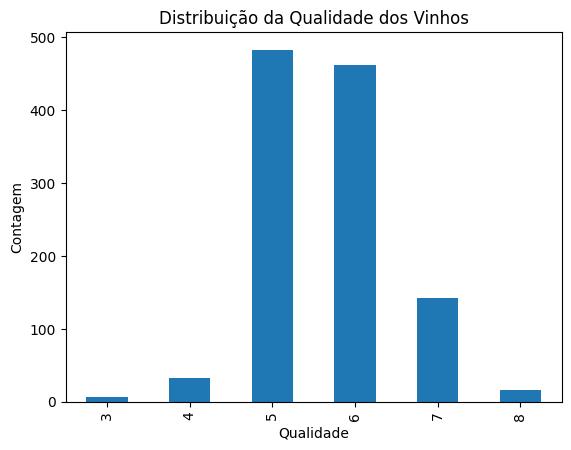

In [10]:
# Analisando a distribuição da variável 'quality'
df_vinhos['quality'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribuição da Qualidade dos Vinhos")
plt.xlabel("Qualidade")
plt.ylabel("Contagem")
plt.show()

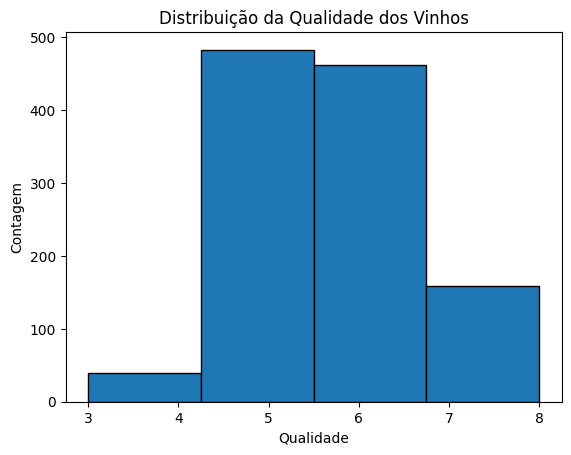

In [11]:
# Analisando a distribuição da variável 'quality' com histograma
plt.hist(df_vinhos['quality'], bins=4, edgecolor='black')
plt.title("Distribuição da Qualidade dos Vinhos")
plt.xlabel("Qualidade")
plt.ylabel("Contagem")
plt.show()

De fato não há nenhum vinho de qualidade muito baixa com nota a baixo de 3 em contra partida não há nenhum 'perfeito' com nota 10. O que me faz pensar que os criterios de avaliação são rigorosos e dependem de vários fatores. Os vinhos desse Dataset se concentram na qualidade 5 e 6.

In [12]:
# Verificando a quantidade de cada categoria na coluna 'quality'
print(df_vinhos['quality'].value_counts().sort_index())

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


Interessante, a maioria dos vinhos ficam na categoria Baixa/Média Qualidade: nota <7. Enquanto apenas 159 vinhos foram classificados como Alta Qualidade: nota ≥ 7 que corresponde ao alvo do nosso Tech Challenge

Agora que já entendi o score vou dar continuidade na análise exploratória

Investigando valores duplicados

In [13]:
 # Verificando valores duplicados
duplicados = df_vinhos.duplicated().sum()
print(f"Quantidade de dados duplicados: {duplicados}\n")

Quantidade de dados duplicados: 0



In [14]:
# Quantos duplicados existem sem o Id?
df_sem_id = df_vinhos.drop(columns=['Id'])
print(f"Duplicados sem Id: {df_sem_id.duplicated().sum()}")

# Ver os registros duplicados
print(df_sem_id[df_sem_id.duplicated(keep=False)].sort_values(by=list(df_sem_id.columns)))

Duplicados sem Id: 125
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
96             5.2             0.340         0.00             1.8      0.050   
98             5.2             0.340         0.00             1.8      0.050   
949            6.0             0.500         0.00             1.4      0.057   
950            6.0             0.500         0.00             1.4      0.057   
951            6.0             0.500         0.00             1.4      0.057   
..             ...               ...          ...             ...        ...   
260           12.8             0.615         0.66             5.8      0.083   
400           13.0             0.470         0.49             4.3      0.085   
404           13.0             0.470         0.49             4.3      0.085   
170           15.0             0.210         0.44             2.2      0.075   
171           15.0             0.210         0.44             2.2      0.075   

     free sulfur

Identifiquei 125 registros duplicados após remoção da coluna Id, que é apenas um índice sem valor preditivo. Os duplicados foram removidos pois não agregam informação nova ao modelo e podem causar vazamento de dados entre treino e teste.

In [15]:
# Removendo Id e duplicados
df_limpo = df_vinhos.drop(columns=['Id']).drop_duplicates()
print(f"Linhas antes: {len(df_vinhos)}")
print(f"Linhas depois: {len(df_limpo)}")

Linhas antes: 1143
Linhas depois: 1018


Vou investigar se com essa remoção de duplicados houve impacto na distribuição da variável Quality

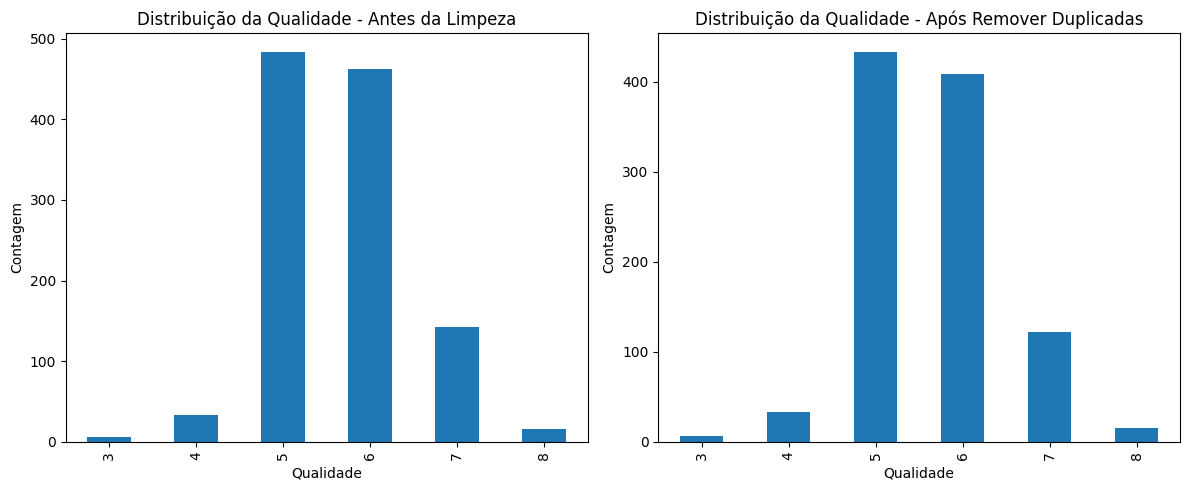

In [16]:
# Analisando a distribuição da variável 'quality' após a remoção de duplicados
# Criar uma figura com 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico do dataframe original
df_vinhos['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title("Distribuição da Qualidade - Antes da Limpeza")
axes[0].set_xlabel("Qualidade")
axes[0].set_ylabel("Contagem")

# Gráfico do dataframe limpo
df_limpo['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title("Distribuição da Qualidade - Após Remover Duplicadas")
axes[1].set_xlabel("Qualidade")
axes[1].set_ylabel("Contagem")

# Ajustar layout para não sobrepor títulos/labels
plt.tight_layout()
plt.show()

In [17]:
# Distribuição no dataframe original
print("Distribuição da Qualidade - Antes da Limpeza")
print(df_vinhos['quality'].value_counts().sort_index())
print("\n")

# Distribuição no dataframe limpo
print("Distribuição da Qualidade - Após Remover Duplicadas")
print(df_limpo['quality'].value_counts().sort_index())

Distribuição da Qualidade - Antes da Limpeza
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


Distribuição da Qualidade - Após Remover Duplicadas
quality
3      6
4     33
5    433
6    409
7    122
8     15
Name: count, dtype: int64


Não houve impacto a maior quantidade de vinhos permanecem concentrados entre as notas 5 e 6

Criando coluna de qualidade entre 0 e 1 para análise de distribuições.

In [18]:
df_limpo['cluster_quality'] = np.where(df_limpo['quality'] >= 7, 1, 0)

Investigando a proporção de vinhos de alta qualidade em relação aos de média e baixa qualidade

In [19]:
# Quantidade e porcentagem
classes = df_limpo["quality"].apply(lambda x: ">= 7" if x >= 7 else "< 7")

resultado = pd.DataFrame({
    "Quantidade": classes.value_counts(),
    "Porcentagem (%)": (classes.value_counts(normalize=True) * 100).round(2)
})

print(resultado)

         Quantidade  Porcentagem (%)
quality                             
< 7             881            86.54
>= 7            137            13.46


Confirmado o desbalanceamento em relação à qualidade. Apenas 13,46% dos vinhos são de alta qualidade (≥ 7), enquanto 86,54% possuem qualidade inferior a 7. Isso representa um desafio para os modelos de Machine Learning, pois haverá poucas amostras de vinhos de alta qualidade para o treinamento.

In [20]:
# Resumo estatístico
print("Resumo estatístico das colunas numéricas:")
print(df_limpo.describe(), "\n")

Resumo estatístico das colunas numéricas:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1018.000000       1018.000000  1018.000000     1018.000000   
mean        8.288507          0.533541     0.268802        2.524411   
std         1.741324          0.183167     0.196229        1.314850   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.645000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1018.000000          1018.000000           1018.000000  1018.000000   
mean      0.087187            15.648821             46.325639     0.996700   
std       0.048506            10.176525             33.123533     0.001916   
min   

O DataFrame está bem organizado e não foi necessário fazer muitas limpezas nos dados. A média da qualidade dos vinhos é de 5,64, com valores entre 3 e 8. Já o açúcar residual apresenta uma variação maior (desvio padrão de 1,31), indicando que os vinhos possuem quantidades diferentes de açúcar. Essa característica pode influenciar a qualidade, mas será preciso analisar melhor essa relação.

Investigando essa hipotese de relação entre açucar residual e qualidade

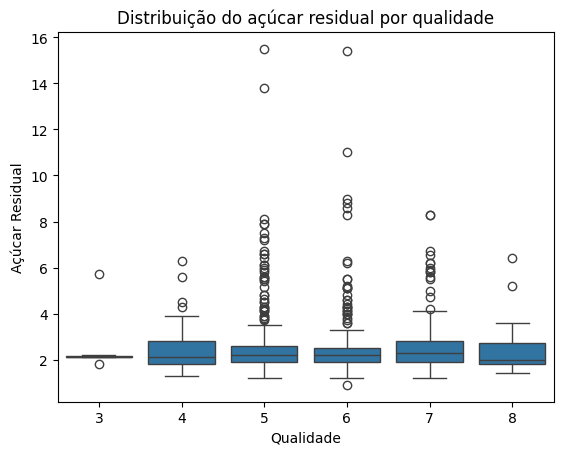

In [21]:
# Analisando a distribuição do açúcar residual por qualidade
sns.boxplot(x='quality', y='residual sugar', data=df_limpo)
plt.title("Distribuição do açúcar residual por qualidade")
plt.xlabel("Qualidade")
plt.ylabel("Açúcar Residual")
plt.show()

In [22]:
# Calculando a correlação entre açúcar residual e qualidade
correlacao = df_limpo['residual sugar'].corr(df_limpo['quality'])
print(f"Correlação entre açúcar residual e qualidade: {correlacao}")

Correlação entre açúcar residual e qualidade: 0.022718223313438424


Conclusão: açucar residual isoladamente não é um fator preditivo de qualidade.

Acho importante estudar e entender esse universo dos vinhos para só depois avançar para a etapa de ML. Vou investigar a relação de outras variaveis com a qualidade

quality                 1.000000
alcohol                 0.485953
sulphates               0.257519
citric acid             0.241565
fixed acidity           0.115826
residual sugar          0.022718
pH                     -0.057592
free sulfur dioxide    -0.071083
chlorides              -0.122214
total sulfur dioxide   -0.182214
density                -0.185187
volatile acidity       -0.409340
Name: quality, dtype: float64


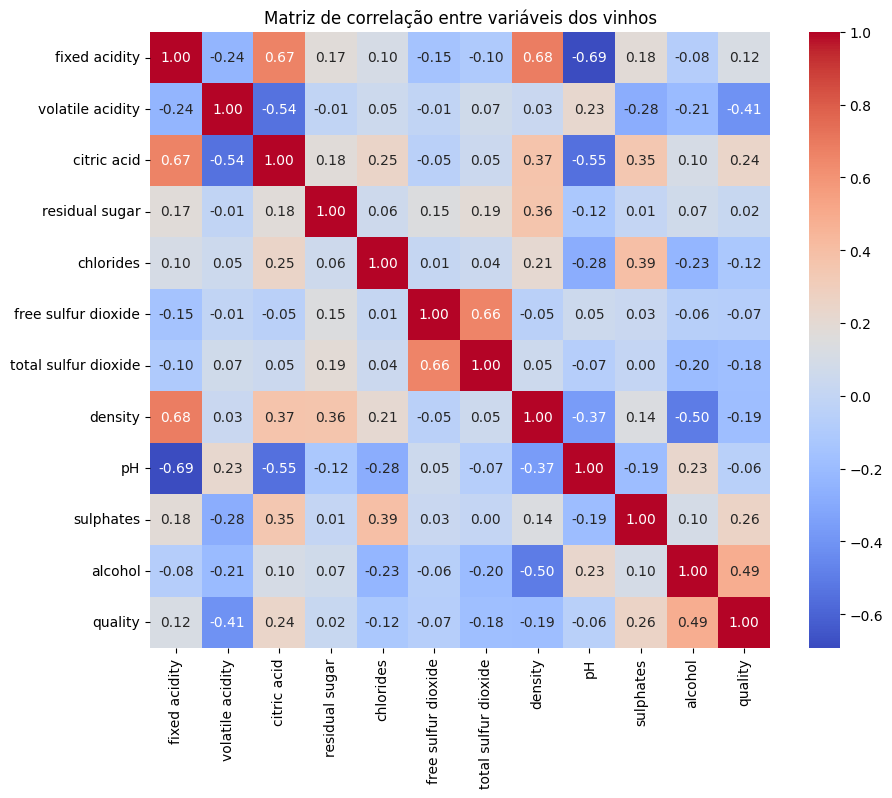

In [23]:
# Remove a coluna 'cluster_quality' do DataFrame
df_corr = df_limpo.drop(columns=['cluster_quality'])

# Calcula a matriz de correlação sem 'Id'
corr = df_corr.corr()

# Foca apenas na correlação com 'quality'
print(corr['quality'].sort_values(ascending=False))

# Visualiza a matriz completa em um heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlação entre variáveis dos vinhos")
plt.show()

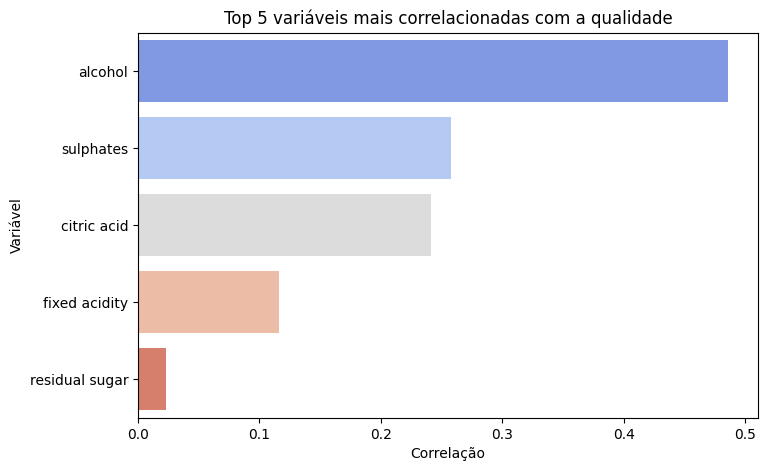

alcohol           0.485953
sulphates         0.257519
citric acid       0.241565
fixed acidity     0.115826
residual sugar    0.022718
Name: quality, dtype: float64


In [24]:
# Remove a coluna 'cluster_quality' antes de calcular correlação
df_corr = df_limpo.drop(columns=['cluster_quality'])

# Calcula correlação apenas com 'quality'
corr_quality = df_corr.corr()['quality'].drop('quality')

# Ordena por importância
corr_quality_sorted = corr_quality.sort_values(ascending=False)

# Mostra as top 5 variáveis mais correlacionadas
top5 = corr_quality_sorted.head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=top5.values, y=top5.index, hue=top5.index, palette="coolwarm", legend=False)
plt.title("Top 5 variáveis mais correlacionadas com a qualidade")
plt.xlabel("Correlação")
plt.ylabel("Variável")
plt.show()

print(top5)

Interessante o teor alcoolico segue como lider de correlação com a qualidade porém, como obeservei anteriormente, ficou claro para mim que é mais de um fator que determina se um vinho tem ou nao boa qualidade

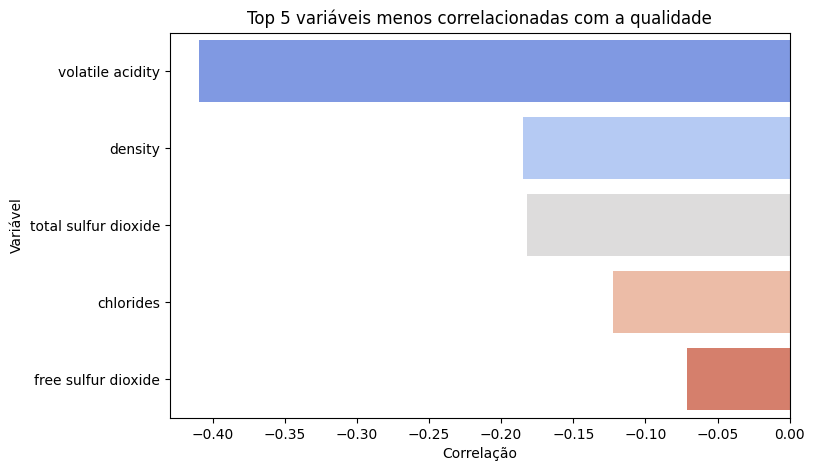

volatile acidity       -0.409340
density                -0.185187
total sulfur dioxide   -0.182214
chlorides              -0.122214
free sulfur dioxide    -0.071083
Name: quality, dtype: float64


In [25]:
# Remove a coluna 'cluster_quality' antes de calcular correlação
df_corr = df_limpo.drop(columns=['cluster_quality'])

# Calcula correlação apenas com 'quality'
corr_quality = df_corr.corr()['quality'].drop('quality')

# Ordena por importância
corr_quality_sorted = corr_quality.sort_values(ascending=True)

# Mostra as top 5 variáveis mais correlacionadas
top5 = corr_quality_sorted.head(5)

plt.figure(figsize=(8,5))
sns.barplot(x=top5.values, y=top5.index, hue=top5.index, palette="coolwarm", legend=False)
plt.title("Top 5 variáveis menos correlacionadas com a qualidade")
plt.xlabel("Correlação")
plt.ylabel("Variável")
plt.show()

print(top5)

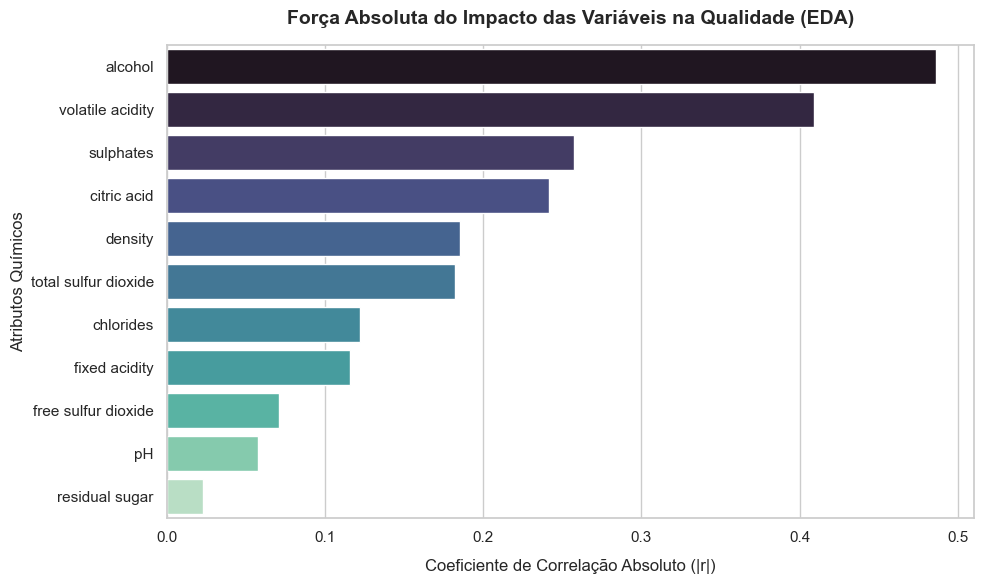

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Preparando os dados e calculando a correlação
df_corr = df_limpo.drop(columns=['cluster_quality'])
corr_quality = df_corr.corr()['quality'].drop('quality')

# 2. Criando um DataFrame com a força absoluta da correlação
df_forca_corr = pd.DataFrame({
    'Variável': corr_quality.index,
    'Correlação Real': corr_quality.values,
    'Força Absoluta': corr_quality.abs().values  # Transforma tudo em positivo
}).sort_values(by='Força Absoluta', ascending=False)

# 3. Configurando o gráfico visual
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plotando as variáveis por ordem de impacto absoluto
sns.barplot(
    x='Força Absoluta', 
    y='Variável', 
    data=df_forca_corr, 
    palette="mako",
    hue='Variável',
    legend=False
)

plt.title('Força Absoluta do Impacto das Variáveis na Qualidade (EDA)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coeficiente de Correlação Absoluto (|r|)', fontsize=12, labelpad=10)
plt.ylabel('Atributos Químicos', fontsize=12)

plt.tight_layout()
plt.show()

Verificando as variaveis que menos estão correlacionada com a qualidade do vinho, oque pode indicar váriaveis independentes que não influenciam a variavel target.

#### Pensando no modelo

Normalização ou Padronização?

1) É importante verificar a distribuição de todas as variaveis para identificar e decidir entre normalizar ou padronizar.
- Normalização: Transformam os dados em 0 e 1, mas sensivel a outliers
- Padronização: Ajusta a escala dos dados utilizando o desvio padrão, mais robusto a outliers.

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

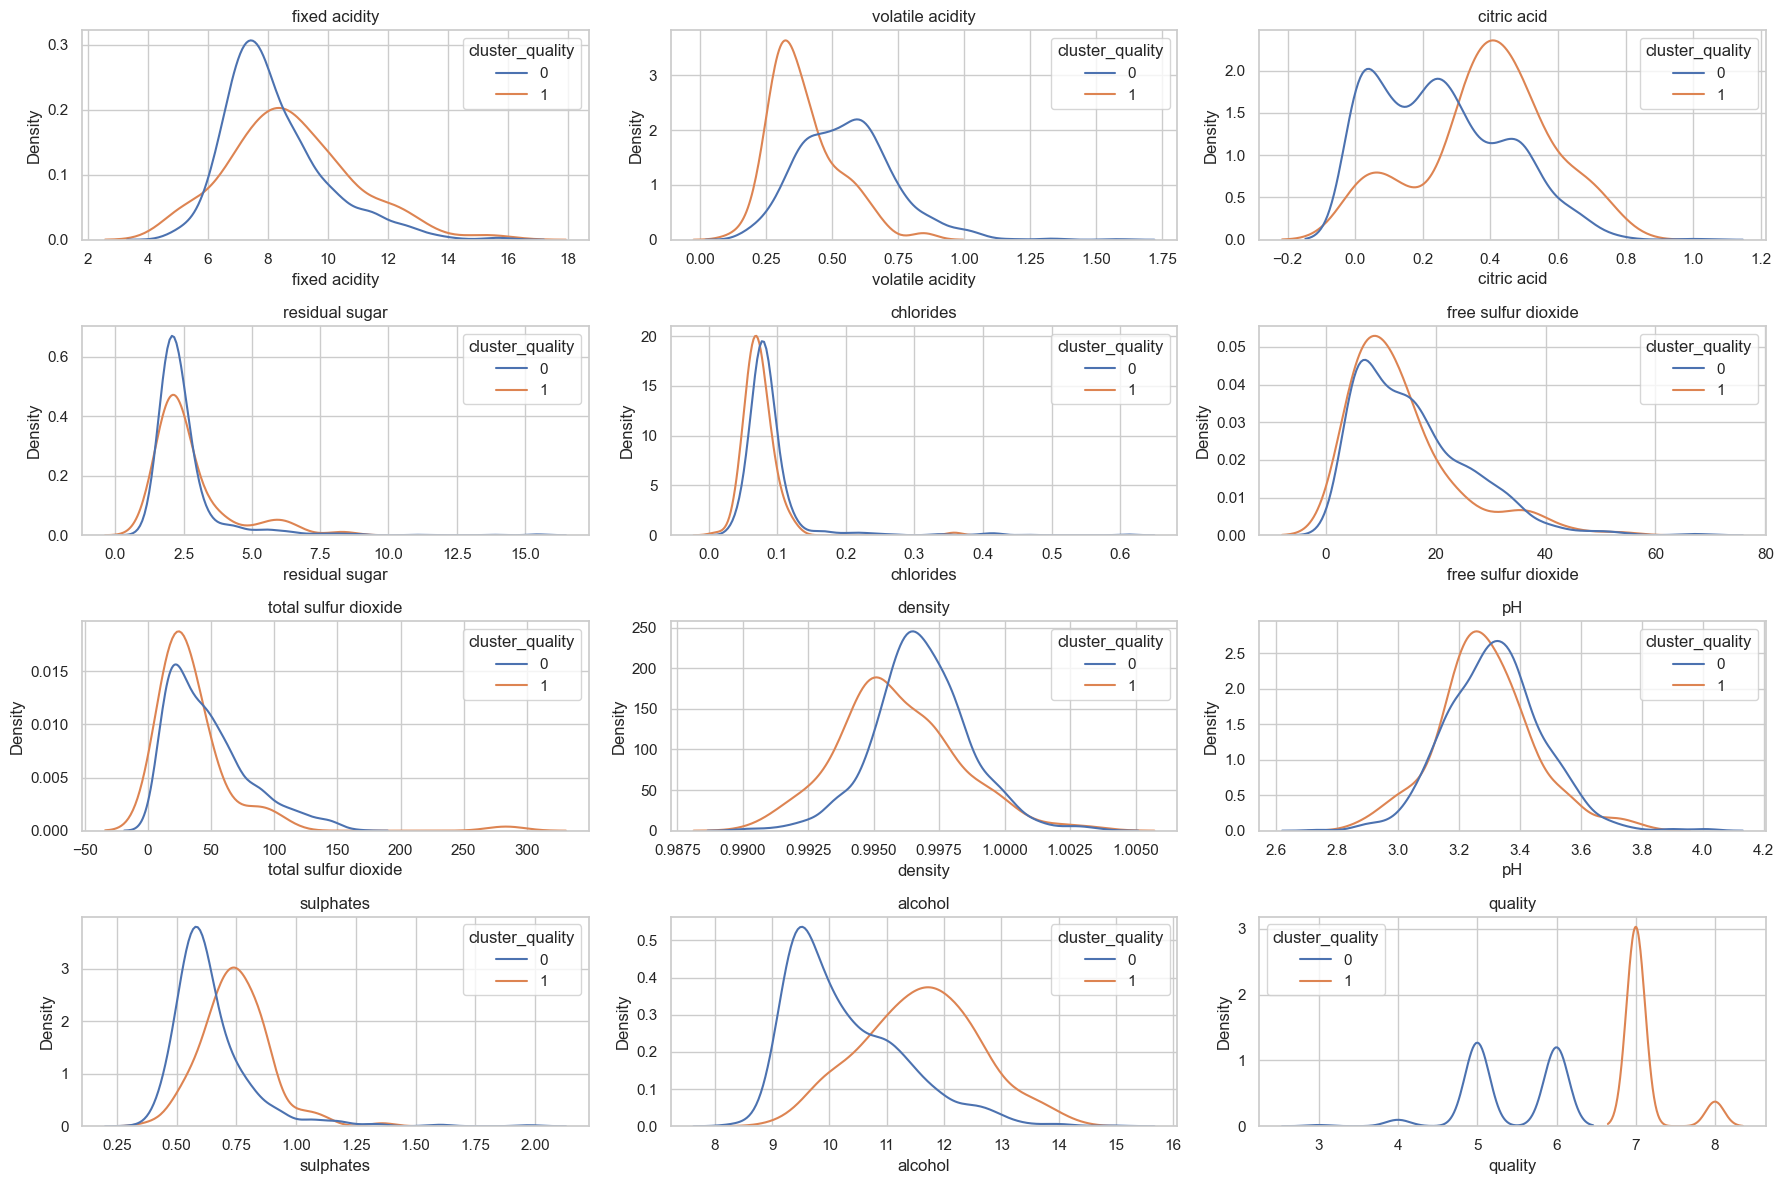

In [28]:
# colunas numéricas sem a target
cols = [col for col in df_limpo.columns if col != 'cluster_quality']

# layout automático
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):

    sns.kdeplot(
        data=df_limpo,
        x=col,
        hue='cluster_quality',
        fill=False,   # apenas linhas
        common_norm=False,
        ax=ax
    )

    ax.set_title(col)

# remove eixos vazios
for i in range(len(cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Podemos ver que entre os cluster de qualidade dos vinhos, temos uma diferença grande nas principias váriaveis independentes, oque pode significar que é necessário ajustar a distribuição dos dados entre 1 e 0 para evitar possiveis vies de um dentro da base de teste.

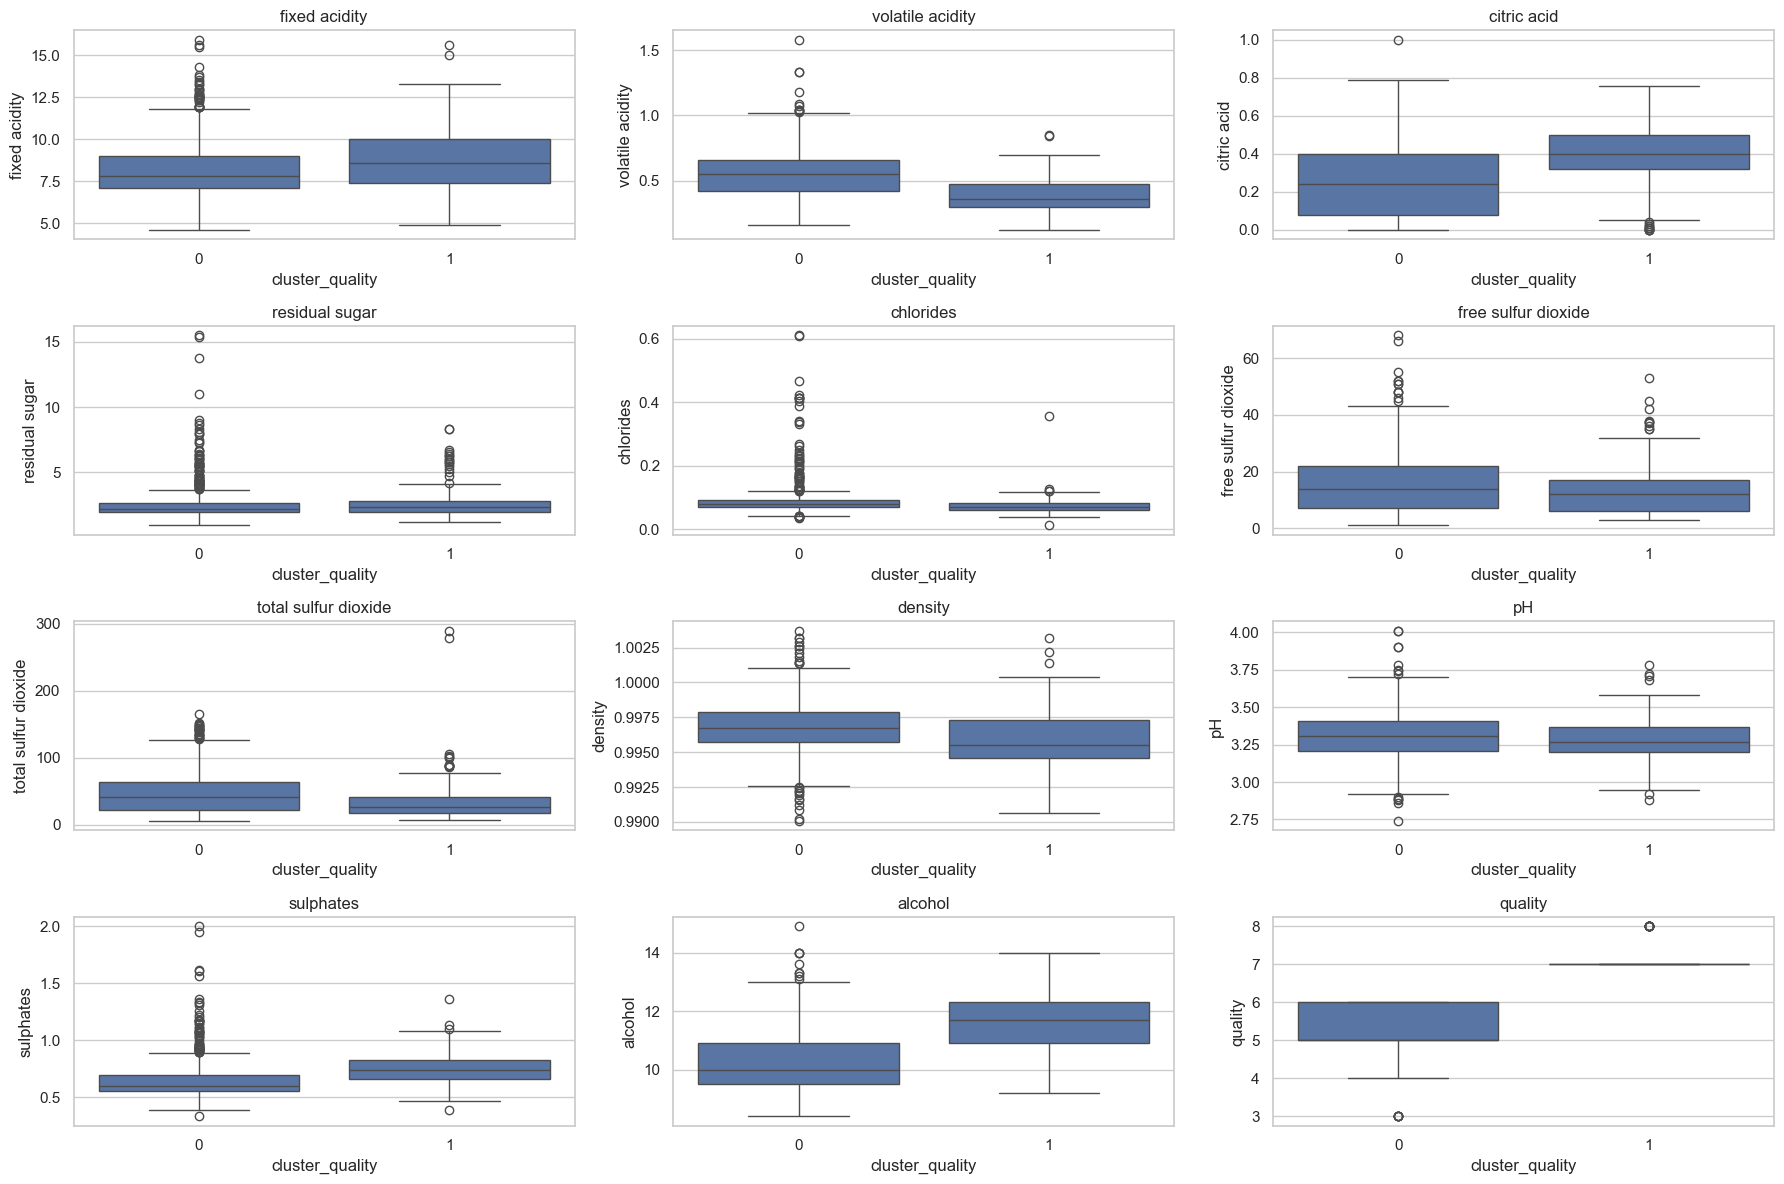

In [29]:

# colunas numéricas sem a target
cols = [col for col in df_limpo.columns if col != 'cluster_quality']

# layout automático
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, cols):

    sns.boxplot(
        data=df_limpo,
        x='cluster_quality',
        y=col,
        ax=ax
    )

    ax.set_title(col)

# remove gráficos vazios
for i in range(len(cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Os boxplot mostram que existe muitos outliers dentro das váriaveis independentes, oque indica que a padronização das escalas pode beneficiar o modelo.

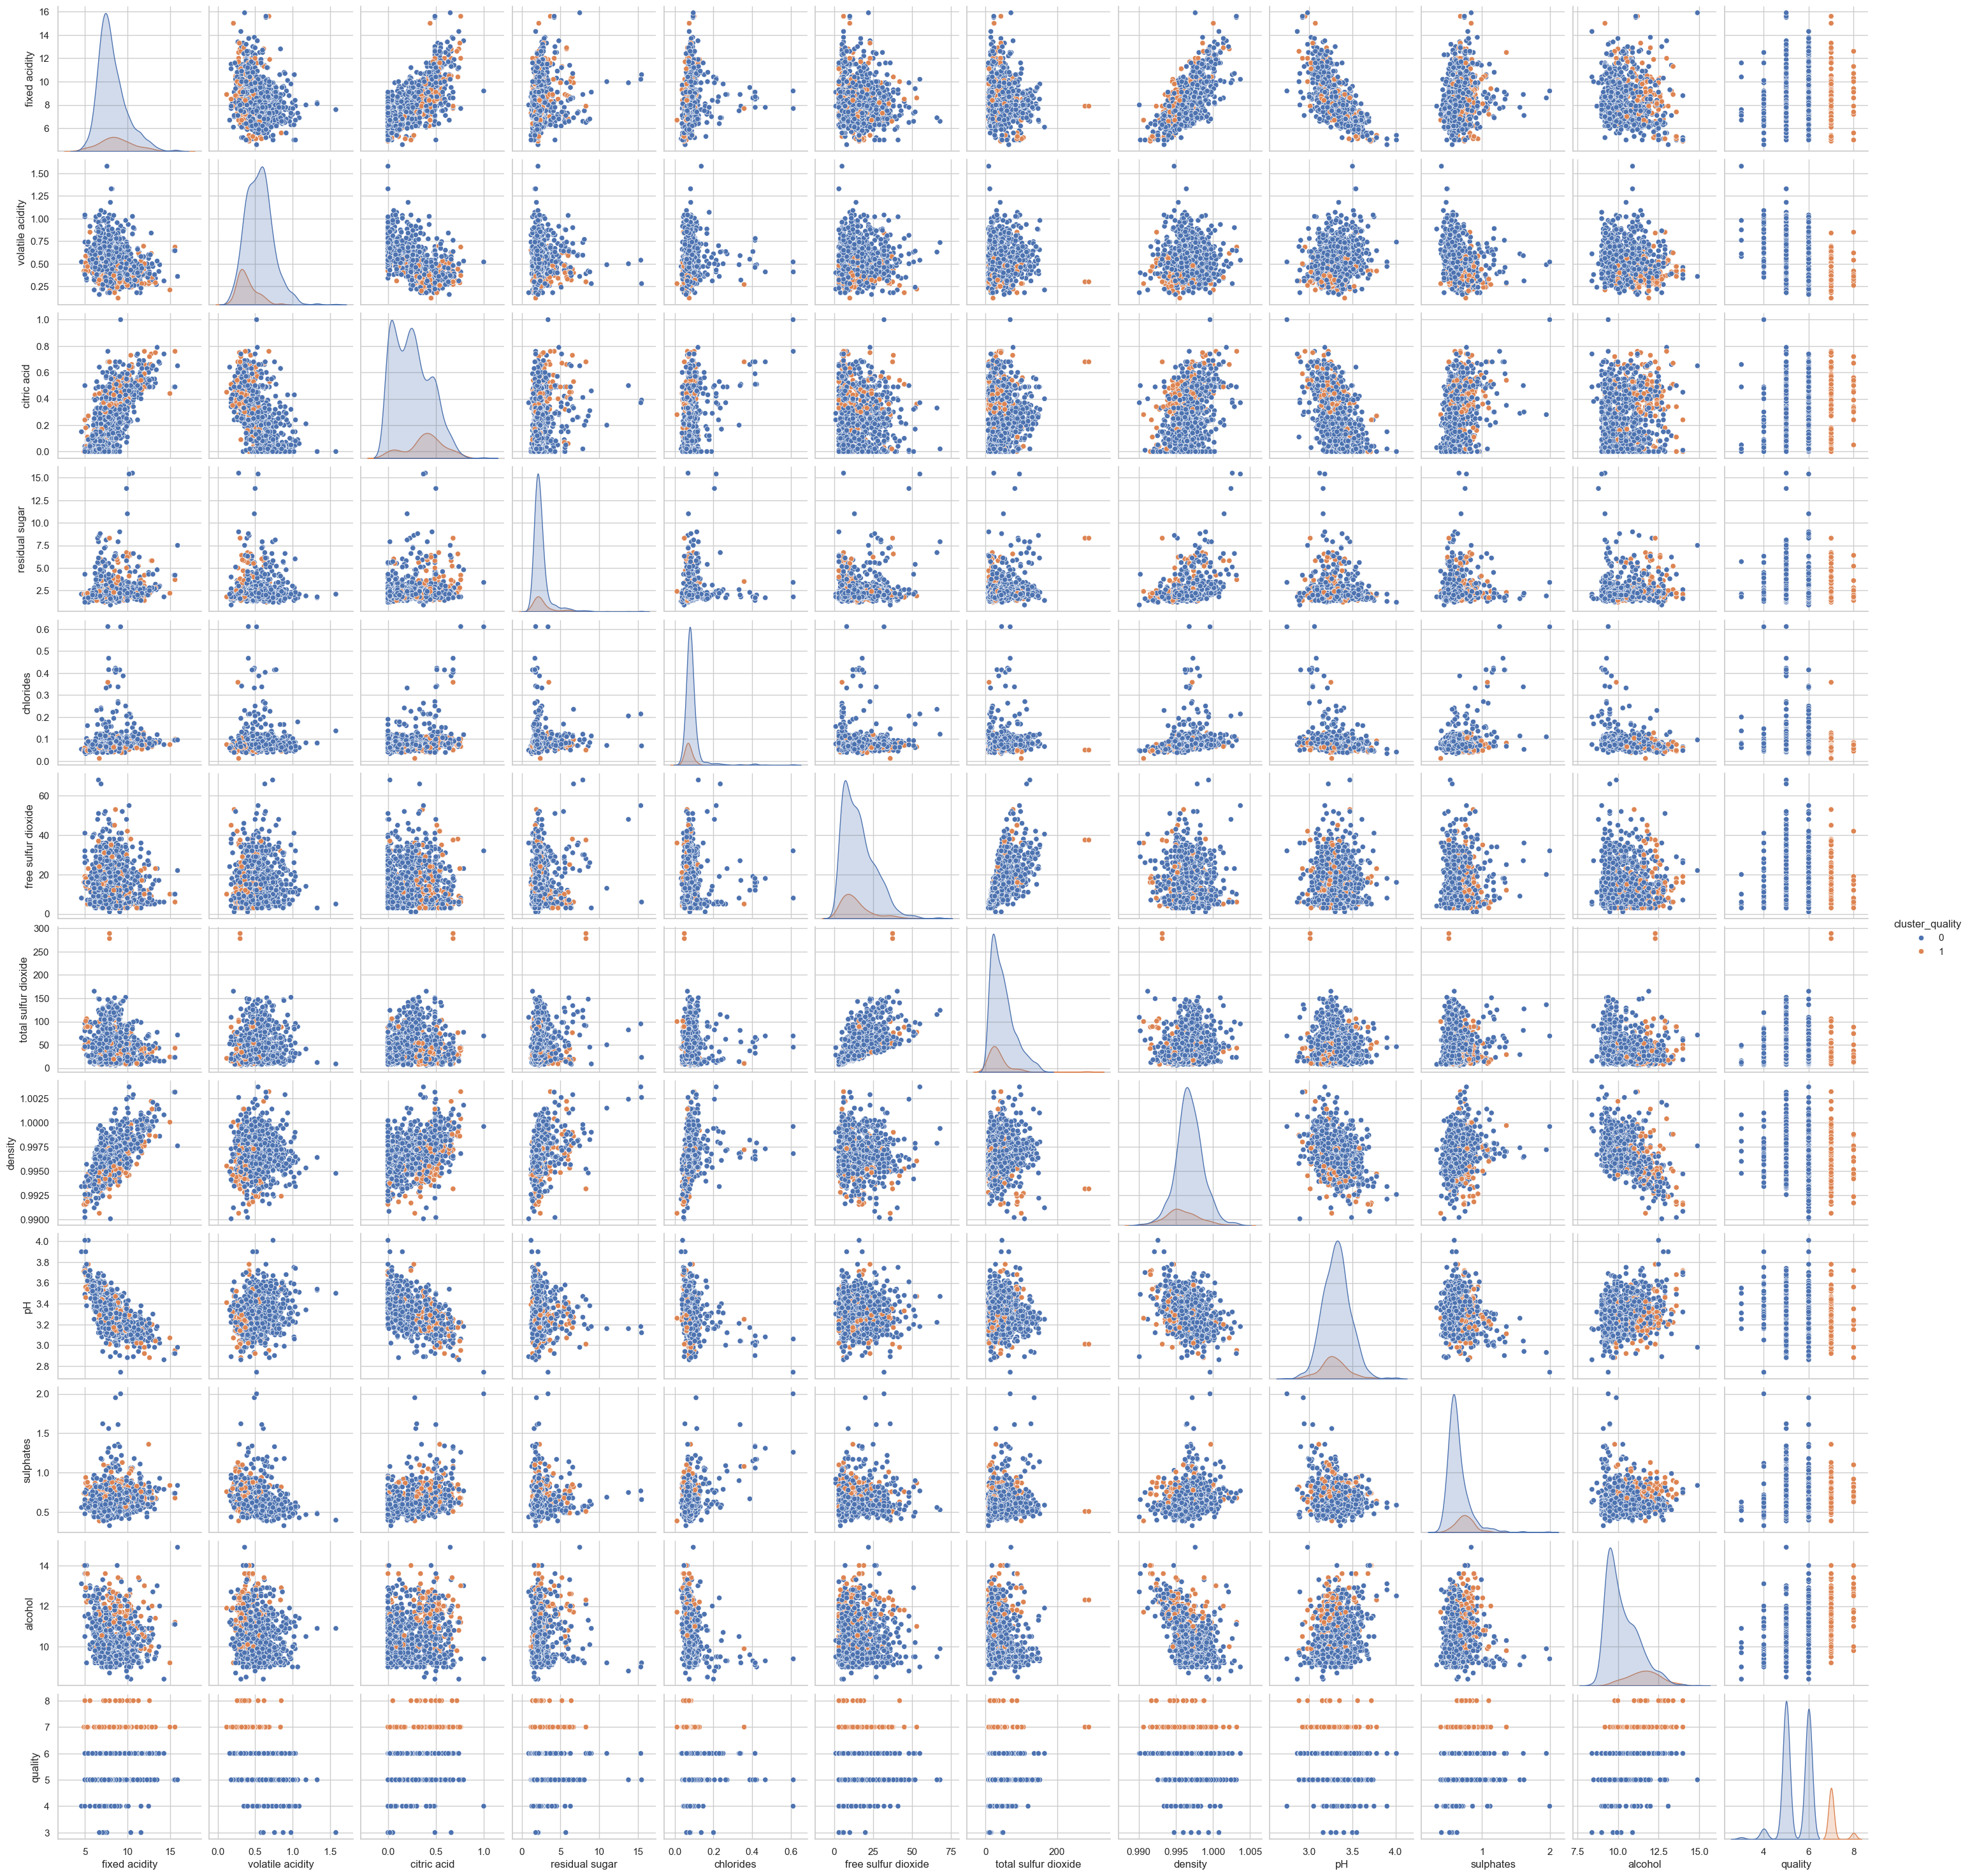

In [30]:
sns.pairplot(df_limpo, hue='cluster_quality')
plt.show()

o Gráfico de pair plot pode nos indicar quais são as váriaveis independentes e quais possuem correlação com outras variaveis.

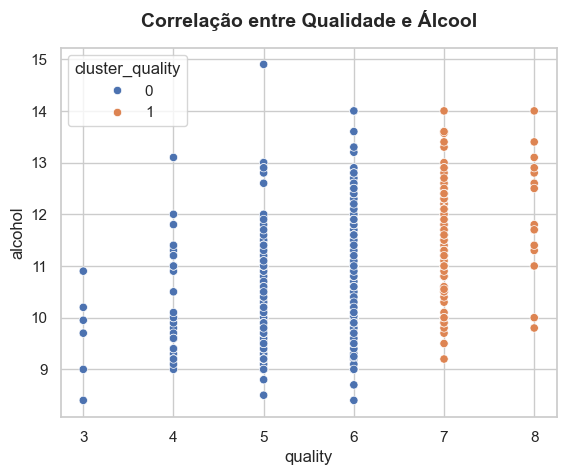

In [31]:
sns.scatterplot(data=df_limpo, y="alcohol", x='quality' ,hue='cluster_quality')
plt.title('Correlação entre Qualidade e Álcool', fontsize=14, fontweight='bold', pad=15)
plt.show()

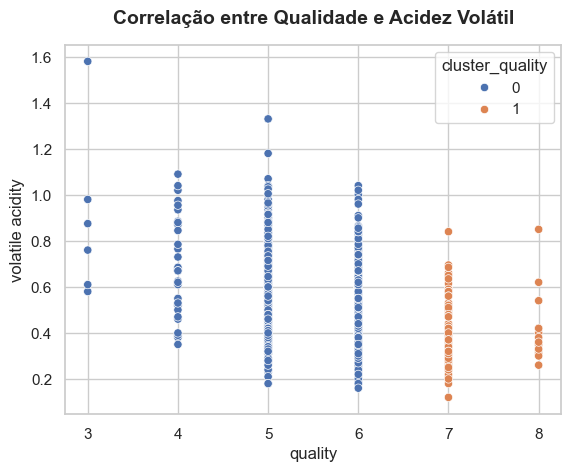

In [32]:
sns.scatterplot(data=df_limpo, y="volatile acidity", x='quality' ,hue='cluster_quality')
plt.title('Correlação entre Qualidade e Acidez Volátil', fontsize=14, fontweight='bold', pad=15)
plt.show()

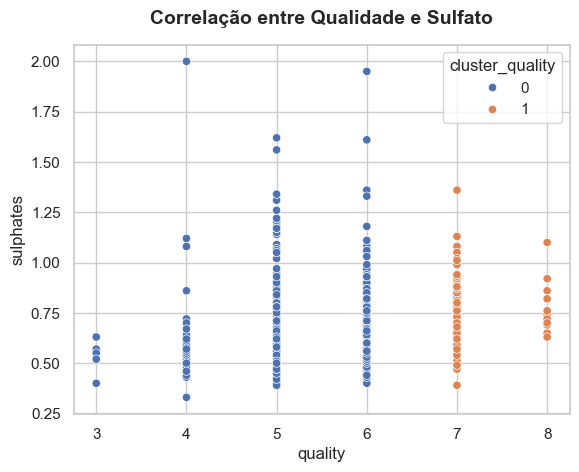

In [33]:
sns.scatterplot(data=df_limpo, y="sulphates", x='quality' ,hue='cluster_quality')
plt.title('Correlação entre Qualidade e Sulfato', fontsize=14, fontweight='bold', pad=15)
plt.show()

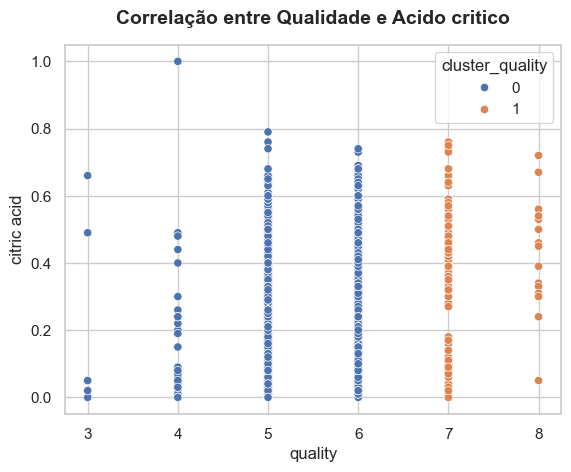

In [34]:
sns.scatterplot(data=df_limpo, y="citric acid", x='quality' ,hue='cluster_quality')
plt.title('Correlação entre Qualidade e Acido critico', fontsize=14, fontweight='bold', pad=15)
plt.show()

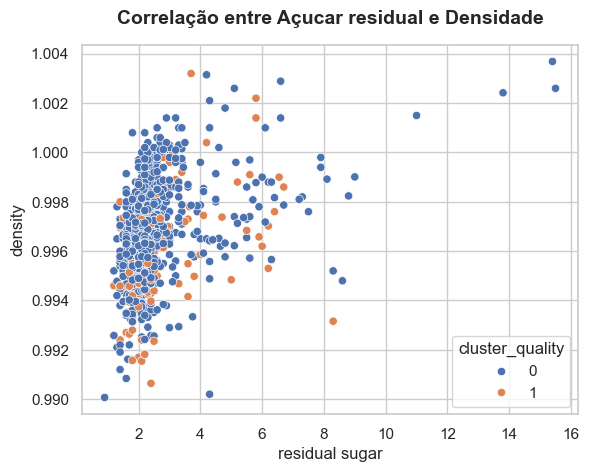

In [35]:
sns.scatterplot(data=df_limpo, x="residual sugar", y='density' ,hue='cluster_quality')
plt.title('Correlação entre Açucar residual e Densidade', fontsize=14, fontweight='bold', pad=15)
plt.show()

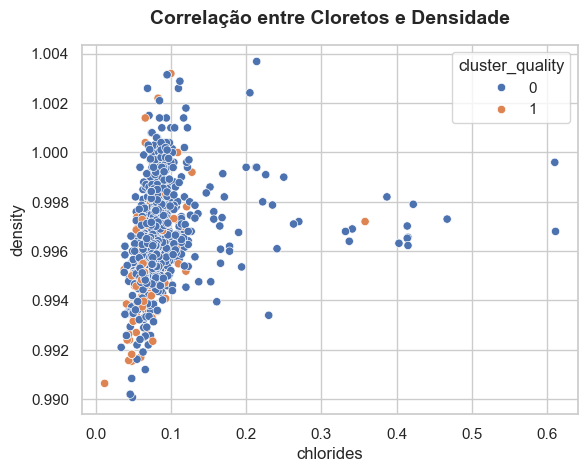

In [36]:
sns.scatterplot(data=df_limpo, x="chlorides", y='density' ,hue='cluster_quality')
plt.title('Correlação entre Cloretos e Densidade', fontsize=14, fontweight='bold', pad=15)
plt.show()

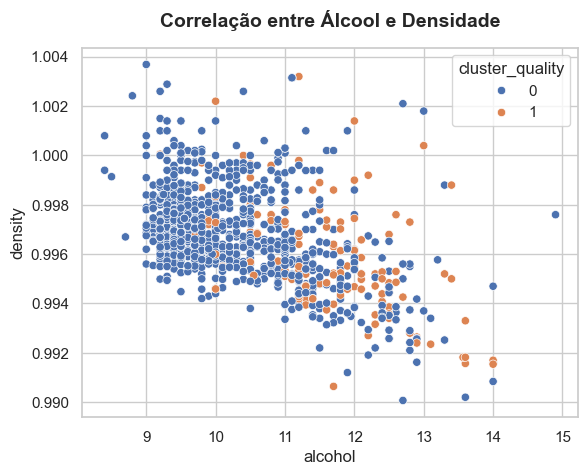

In [37]:
sns.scatterplot(data=df_limpo, x="alcohol", y='density' ,hue='cluster_quality')
plt.title('Correlação entre Álcool e Densidade', fontsize=14, fontweight='bold', pad=15)
plt.show()

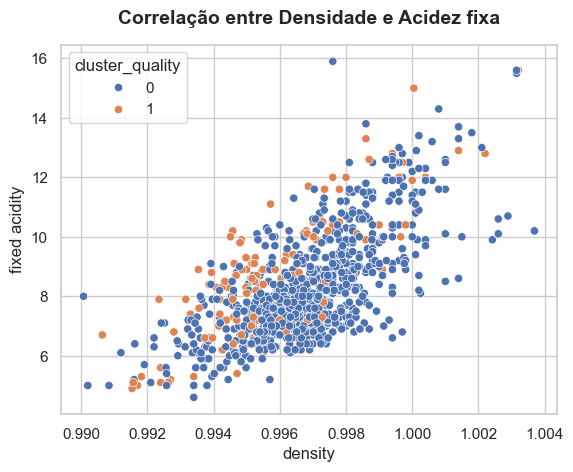

In [38]:
sns.scatterplot(data=df_limpo, y="fixed acidity", x='density' ,hue='cluster_quality')
plt.title('Correlação entre Densidade e Acidez fixa', fontsize=14, fontweight='bold', pad=15)
plt.show()

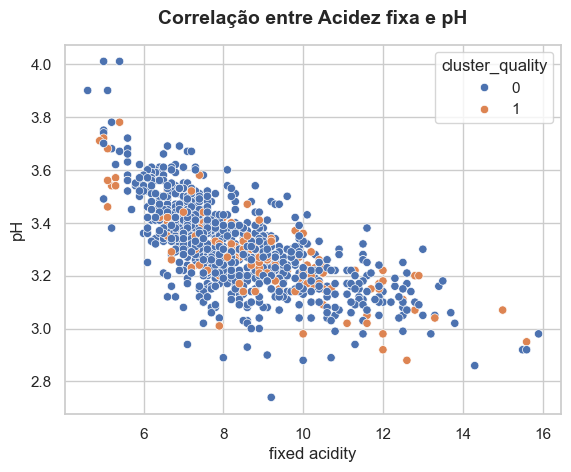

In [39]:
sns.scatterplot(data=df_limpo, x="fixed acidity", y='pH' ,hue='cluster_quality')
plt.title('Correlação entre Acidez fixa e pH', fontsize=14, fontweight='bold', pad=15)
plt.show()

A sequencia de scatter explora a correlação entre os elementos do vinho.

Minha duvida aqui é, são independentes ou dependentes? Será que vale o aprofundamento de análise ou talvez uma pesquisa externa para entender? 

O fato é, Densidade e Alcool são as váriaveis que mais estão correlacionadas com nossa váriavel target (Qualidade)

Localizei esse artigo que pode ajudar a esclarecer essa dúvida: https://www.stat.cmu.edu/capstoneresearch/fall2024/315files_f24/team8.html#1_The_Strongest_Predictor_of_Wine_Quality

## 💾 Base Tratada

A base limpa foi exportada para `data/base_wine_limpa.csv` e será 
utilizada como ponto de partida por todos os modelos.

> **Nota sobre pré-processamento:** Normalização e padronização serão 
> aplicadas individualmente em cada notebook de modelagem, uma vez que 
> cada algoritmo tem requisitos específicos. A **Regressão Logística** 
> exige normalização por ser sensível à escala das variáveis, enquanto 
> o **Random Forest** e o **XGBoost** não necessitam, pois são baseados 
> em árvores de decisão e robustos a diferenças de escala.

Sobre a dúvida identificada na análise — **densidade e álcool são 
quimicamente dependentes**: durante a fermentação, o açúcar se transforma 
em álcool, reduzindo naturalmente a densidade do líquido. Essa relação 
foi confirmada pelo heatmap de correlação e pelo artigo de referência 
da Carnegie Mellon University (CMU, 2024). O Random Forest lida bem 
com essa dependência pela aleatorização das variáveis em cada árvore.

In [40]:
# Exportando a base de dados limpa para um novo arquivo CSV
df_limpo.to_csv('..//data/base_wine_limpa.csv', index=False)